<a href="https://colab.research.google.com/github/FranGa06/Telecom-x-Challenge-2/blob/main/Telecomx2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
from pandas import json_normalize

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df_raw = pd.read_json(url)

d1 = json_normalize(df_raw['customer'])
d2 = json_normalize(df_raw['phone'])
d3 = json_normalize(df_raw['internet'])
d4 = json_normalize(df_raw['account'])

df = pd.concat([df_raw[['customerID', 'Churn']], d1, d2, d3, d4], axis=1)

df.columns = [col.lower() for col in df.columns]
df.columns = df.columns.str.replace('.', '_', regex=False)

df['charges_monthly'] = pd.to_numeric(df['charges_monthly'], errors='coerce')
df['charges_total'] = pd.to_numeric(df['charges_total'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

df = df.fillna(0)
df = df[df['churn'].isin(['No', 'Yes'])].copy()

df_ia = df.drop(columns=['customerid'])
df_ia['churn'] = df_ia['churn'].map({'Yes': 1, 'No': 0})
df_ia = pd.get_dummies(df_ia)

print(df_ia.shape)

(7043, 46)


In [12]:
from imblearn.over_sampling import SMOTE

X = df_ia.drop('churn', axis=1)
y = df_ia['churn']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(y_res.value_counts())

churn
0    5174
1    5174
Name: count, dtype: int64


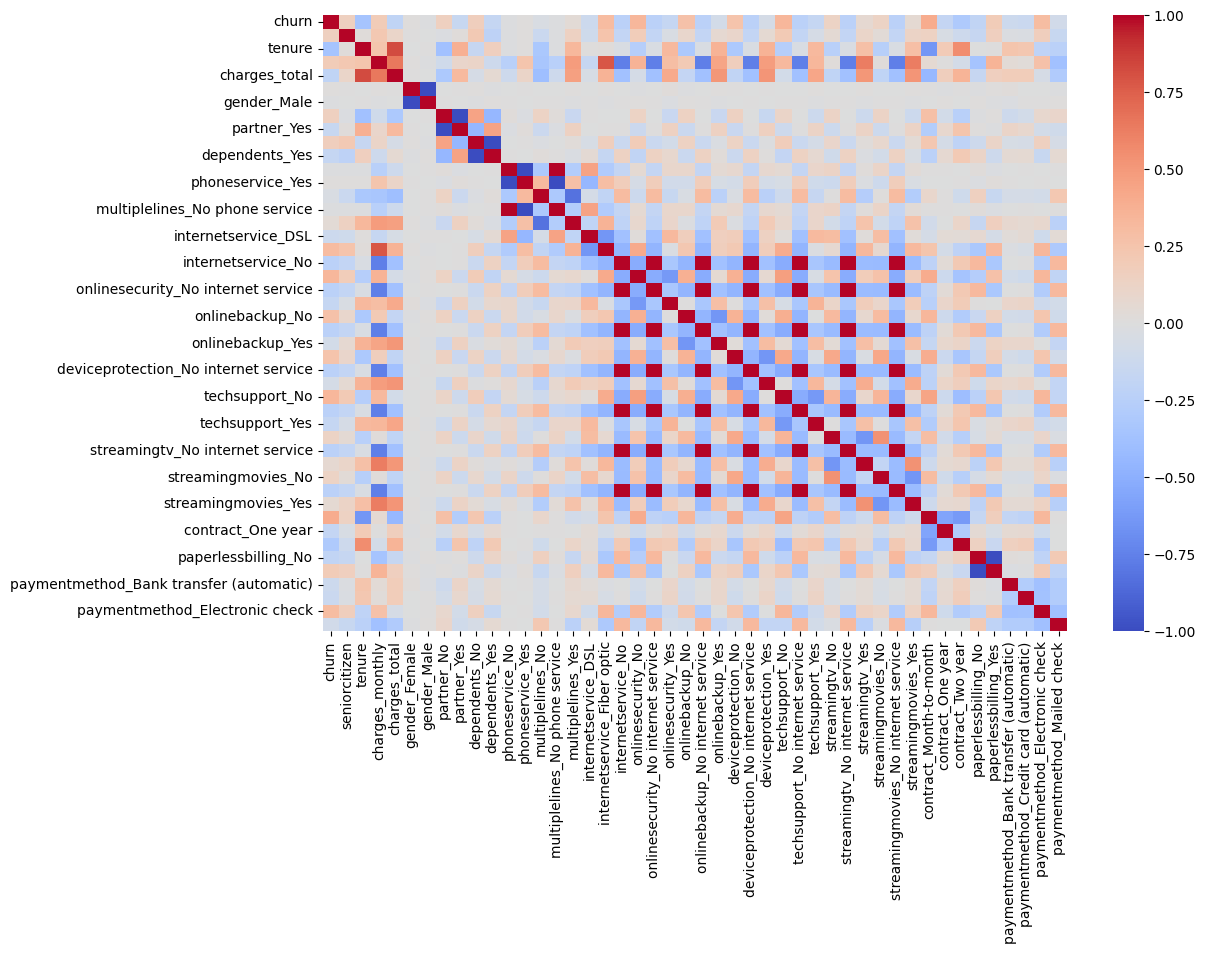

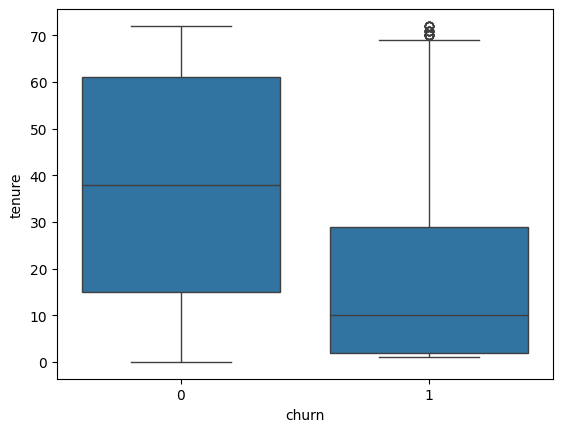

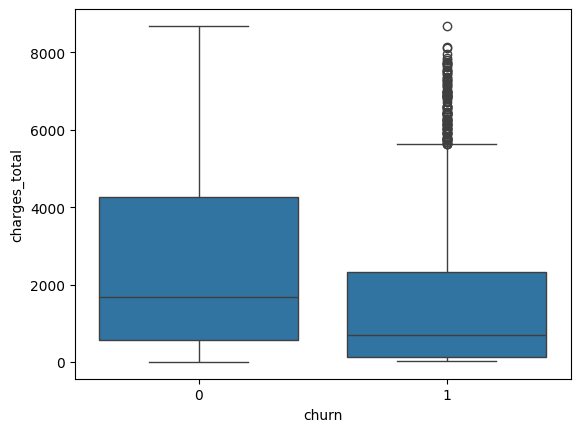

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_ia.corr(), cmap='coolwarm')
plt.show()

sns.boxplot(x='churn', y='tenure', data=df_ia)
plt.show()

sns.boxplot(x='churn', y='charges_total', data=df_ia)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

m1 = LogisticRegression()
m1.fit(X_train_s, y_train)

m2 = RandomForestClassifier()
m2.fit(X_train, y_train)

RandomForestClassifier()

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1027
           1       0.89      0.83      0.86      1043

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1027
           1       0.89      0.83      0.86      1043

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



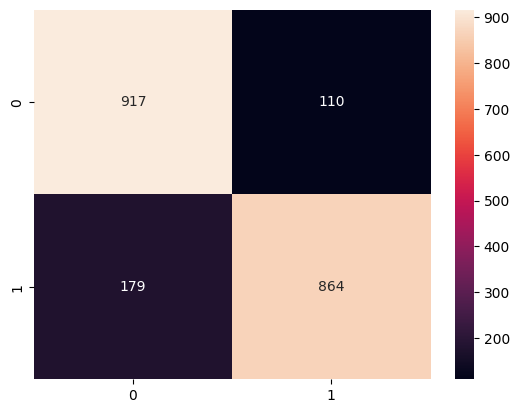

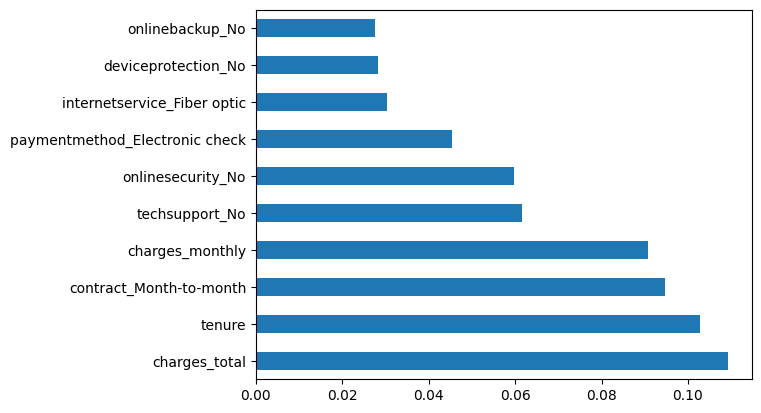

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, m1.predict(X_test_s)))
print(classification_report(y_test, m2.predict(X_test)))

matriz = confusion_matrix(y_test, m2.predict(X_test))
sns.heatmap(matriz, annot=True, fmt='d')
plt.show()

importancias = pd.Series(m2.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False).head(10).plot(kind='barh')
plt.show()

##Desafío Telecom X 2

Conclusiones:

En esta segunda parte investigué la inteligencia artificial para tratar de predecir que clientes se van a dar de baja.



Modelos:

Regresión logistica y random forest son los dos modelos que probé, el segundo gana con diferencia. Detecta mucho mejor a los que clientes que se van a dar de baja.


Resultados observados:

EL contrato es la clave: los que pagan por mes tienen mas probabilidades de irse, a diferencia que los que pagan de forma anual.

Los clientes nuevos: cuanto menos tiempo un cliente lleva en la empresa, mas chances de que solicite la baja.

EL problema con la fibra: los datos informan que los clientes con fibra optica contratada suelen darse de baja mas seguido. Prtobablemente ese servicio o sea mas caro o ande de peor forma.

Soporte: Si el cliente no tiene contratado el soporte tecnico, es mas probable que se vaya en cuanot tenga un problema, segun los datos.

Sugerencias finales:

Creo que se debería prestar mas atencion a los nuevos clientes, estar mas atentos a ellos para retenerlos lo maximo posible.

Ofrecer descuentos o algun tipo de beneficio para que los clientes se sientan tentados a contratar el servicio de forma anual.

Revisar el servicio de fibra optica, que es lo que ofrece, por cuanto dinero,  si el servicio funciona bien, que tiene en contra del servicio DSL.

Ofrecer un equilibrio de beneficios que incluyan el soporte tecnico personalizado.